**OPEN ENDED LAB**

Project Idea: Employee Attrition Analyzer

NAME: ALI MUHAMMAD

ROLL NO: 24F-AI-203

SECTION: A1

**IMPORT LIBRARIES AND LOAD DATASET**

In [25]:
# Load the HR employee data

import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix


file_path = "WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "pavansubhasht/ibm-hr-analytics-attrition-dataset",
    file_path
)

print("Dataset shape:", df.shape)
df.head()

/tmp/ipykernel_897/3739234368.py:25: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Dataset shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


**A QUICK LOOK AT THE DATA**

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  Job

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000



Missing values:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole     

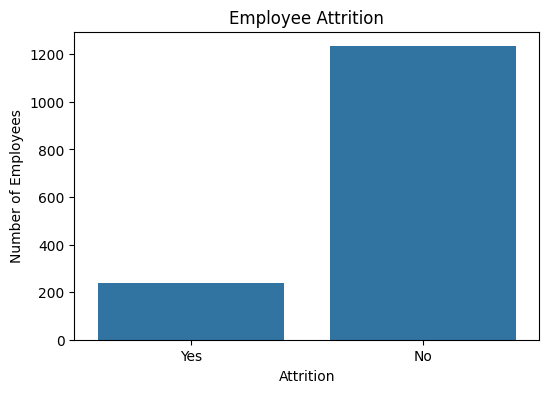

In [31]:
# Take a quick look at the dataset

print("Dataset information:")
df.info()

print("\nBasic statistics:")
display(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

print("\nAttrition count:")
print(df["Attrition"].value_counts())

# Check the target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Attrition")

plt.title("Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

**PREPARE THE DATA**

In [26]:
# Seperation process of the employee details from the result which we want to predict

remove_columns = [
    "Attrition",
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
]

X = df.drop(columns=remove_columns)
y = df["Attrition"].map({"No": 0, "Yes": 1})

categorical_columns = X.select_dtypes(include="object").columns
numerical_columns = X.select_dtypes(exclude="object").columns



print("Categorical columns :", len(categorical_columns))
print("Numerical columns :", len(numerical_columns))

Categorical columns : 7
Numerical columns : 23


**CLEAN AND SPLIT THE DATA**

In [27]:

# Clean the  numerical and categorical columns

numeric_process = Pipeline([
    ("fill_missing", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])


category_process = Pipeline([
    ("fill_missing", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore"))
])


preprocessor = ColumnTransformer([
    ("numeric", numeric_process, numerical_columns),
    ("categorical", category_process, categorical_columns)
])


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("Training Records:", X_train.shape[0])
print("Testing Records:", X_test.shape[0])

Training Records: 1176
Testing Records: 294


**TRAIN THE THREE MODELS: Logistic Regression, Decision Tree, and Random Forest**

In [28]:
# Train three different classification models

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

results = []
predictions = {}

for name, model in models.items():

    model_pipe = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    model_pipe.fit(X_train, y_train)

    prediction = model_pipe.predict(X_test)

    predictions[name] = prediction

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, prediction),
        "F1 Score": f1_score(y_test, prediction, zero_division=0)
    })

results_df = pd.DataFrame(results)



print("Model comparison:")
display(results_df.round(4))

Model comparison:


,Model,Accuracy,F1 Score
0,Logistic Regression,0.8605,0.4384
1,Decision Tree,0.8367,0.2727
2,Random Forest,0.8503,0.2414


**CHECK THE CONFUSIN MATRIX**

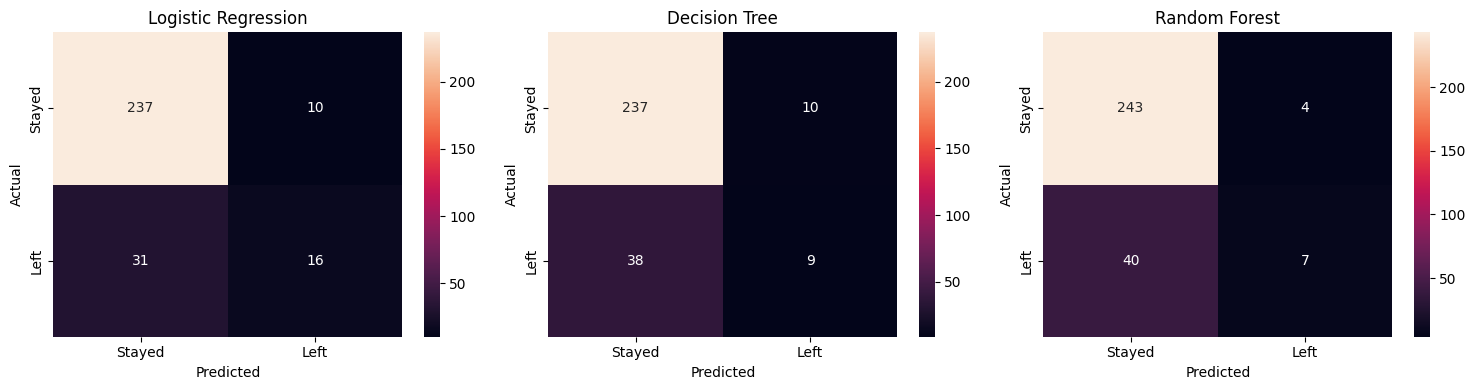

In [29]:
# In this we see how model classify the employees

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, prediction) in zip(axes, predictions.items()):

    cm = confusion_matrix(y_test, prediction)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        ax=ax,
        xticklabels=["Stayed", "Left"],
        yticklabels=["Stayed", "Left"]
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

**FEATURE IMPORTANCE**

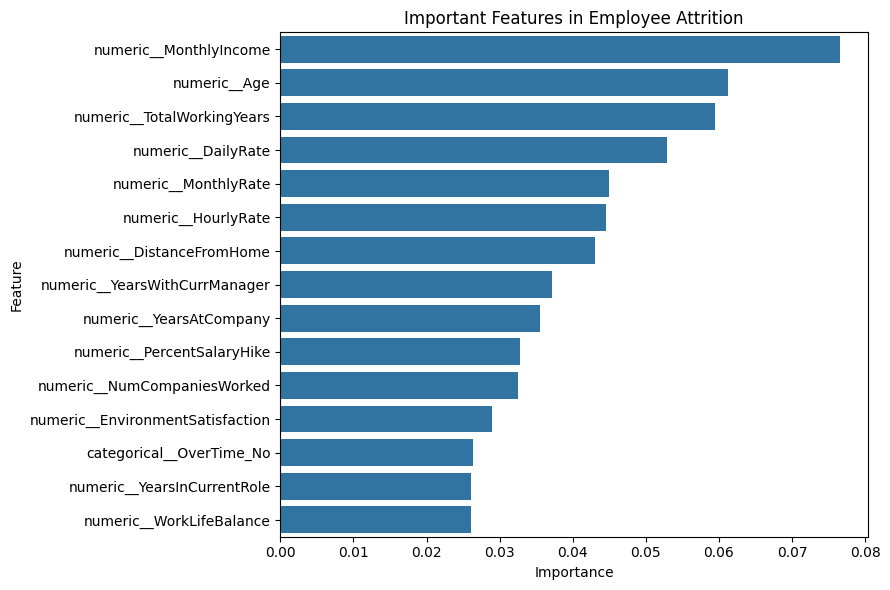

In [30]:
# Find those features that were most useful for the Random Forest

rf_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

rf_pipe.fit(X_train, y_train)

feature_names = rf_pipe.named_steps[
    "preprocessing"
].get_feature_names_out()

importance_values = rf_pipe.named_steps[
    "model"
].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).head(15)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Important Features in Employee Attrition")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**CONCLUSION**

I prepared the HR data and tested three models: Logistic Regression, Decision Tree, and Random Forest. I compared their Accuracy, F1 Score, and Confusion Matrix. The model with the best test results was selected as the better model. I also checked feature importance to see which employee factors were most useful for predicting attrition.